In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Setting visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


In [10]:
# Load dataset Titanic
df = pd.read_csv('../namadataset_raw/data.csv')

print("="*60)
print("📊 DATA TITANIC - INFO AWAL")
print("="*60)
print(f"Total samples: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")
print("\n5 Data Pertama:")
display(df.head())

print("\nInfo Dataset:")
df.info()

📊 DATA TITANIC - INFO AWAL
Total samples: 891
Total features: 12

5 Data Pertama:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Info Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


🔍 ANALISIS MISSING VALUES


,Missing,Percentage (%)
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


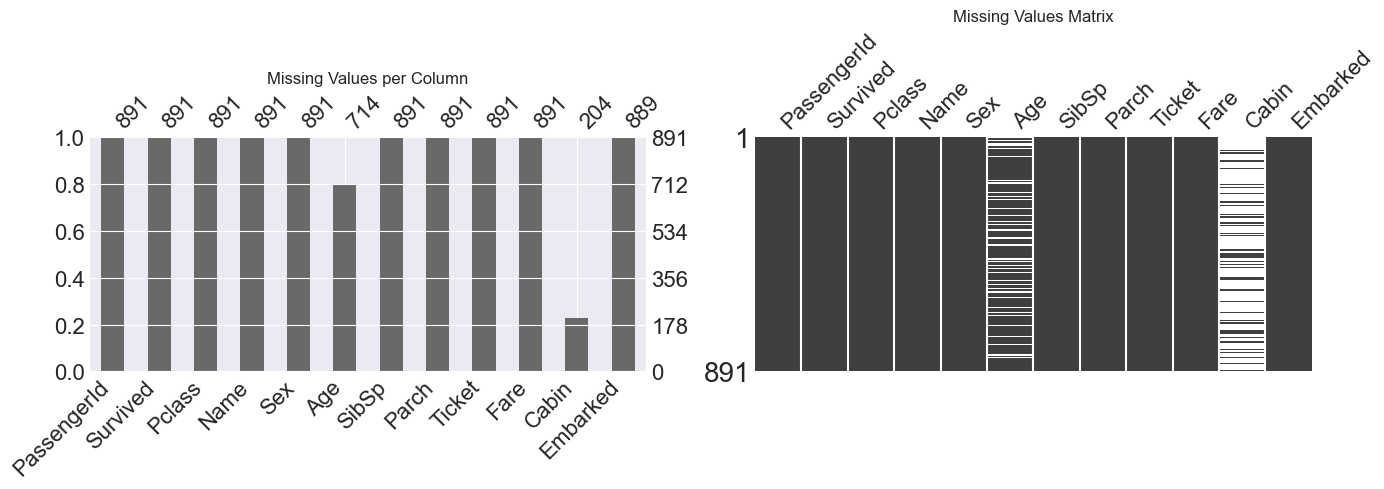

In [12]:
print("="*60)
print("🔍 ANALISIS MISSING VALUES")
print("="*60)

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing': missing,
    'Percentage (%)': missing_percent.round(2)
})

display(missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
msno.bar(df, ax=axes[0])
axes[0].set_title('Missing Values per Column', fontsize=12)

msno.matrix(df, ax=axes[1])
axes[1].set_title('Missing Values Matrix', fontsize=12)

plt.tight_layout()
plt.savefig('missing_values.png', dpi=150)
plt.show()

🎯 ANALISIS TARGET VARIABLE (Survived)


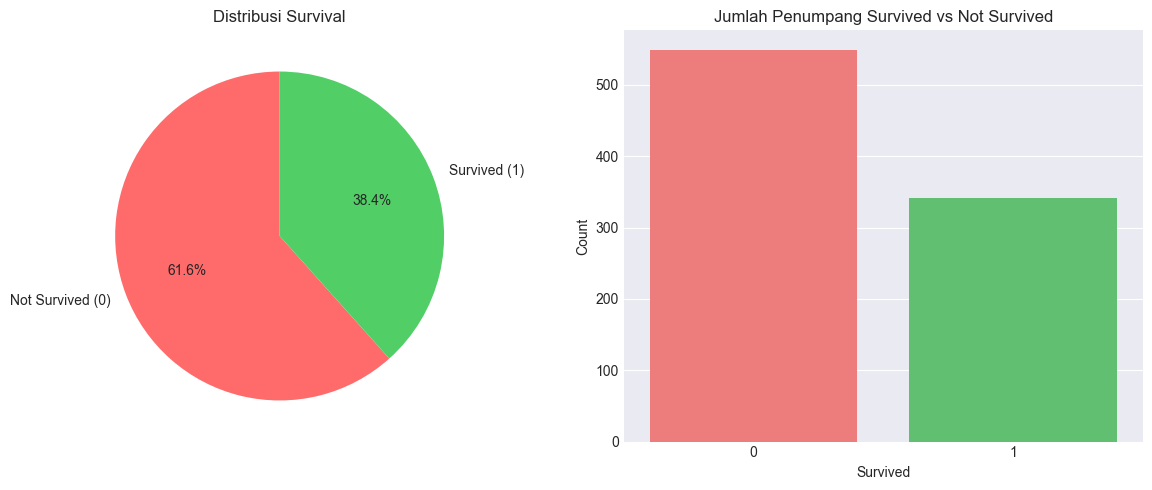


Total Not Survived: 549 (61.6%)
Total Survived: 342 (38.4%)


In [14]:
print("="*60)
print("🎯 ANALISIS TARGET VARIABLE (Survived)")
print("="*60)

survived_counts = df['Survived'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(survived_counts, labels=['Not Survived (0)', 'Survived (1)'], 
            autopct='%1.1f%%', colors=['#ff6b6b', '#51cf66'], startangle=90)
axes[0].set_title('Distribusi Survival')

sns.countplot(data=df, x='Survived', ax=axes[1], palette=['#ff6b6b', '#51cf66'])
axes[1].set_title('Jumlah Penumpang Survived vs Not Survived')
axes[1].set_xlabel('Survived')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

print(f"\nTotal Not Survived: {survived_counts[0]} ({survived_counts[0]/len(df)*100:.1f}%)")
print(f"Total Survived: {survived_counts[1]} ({survived_counts[1]/len(df)*100:.1f}%)")

📊 ANALISIS FITUR NUMERIK VS SURVIVAL


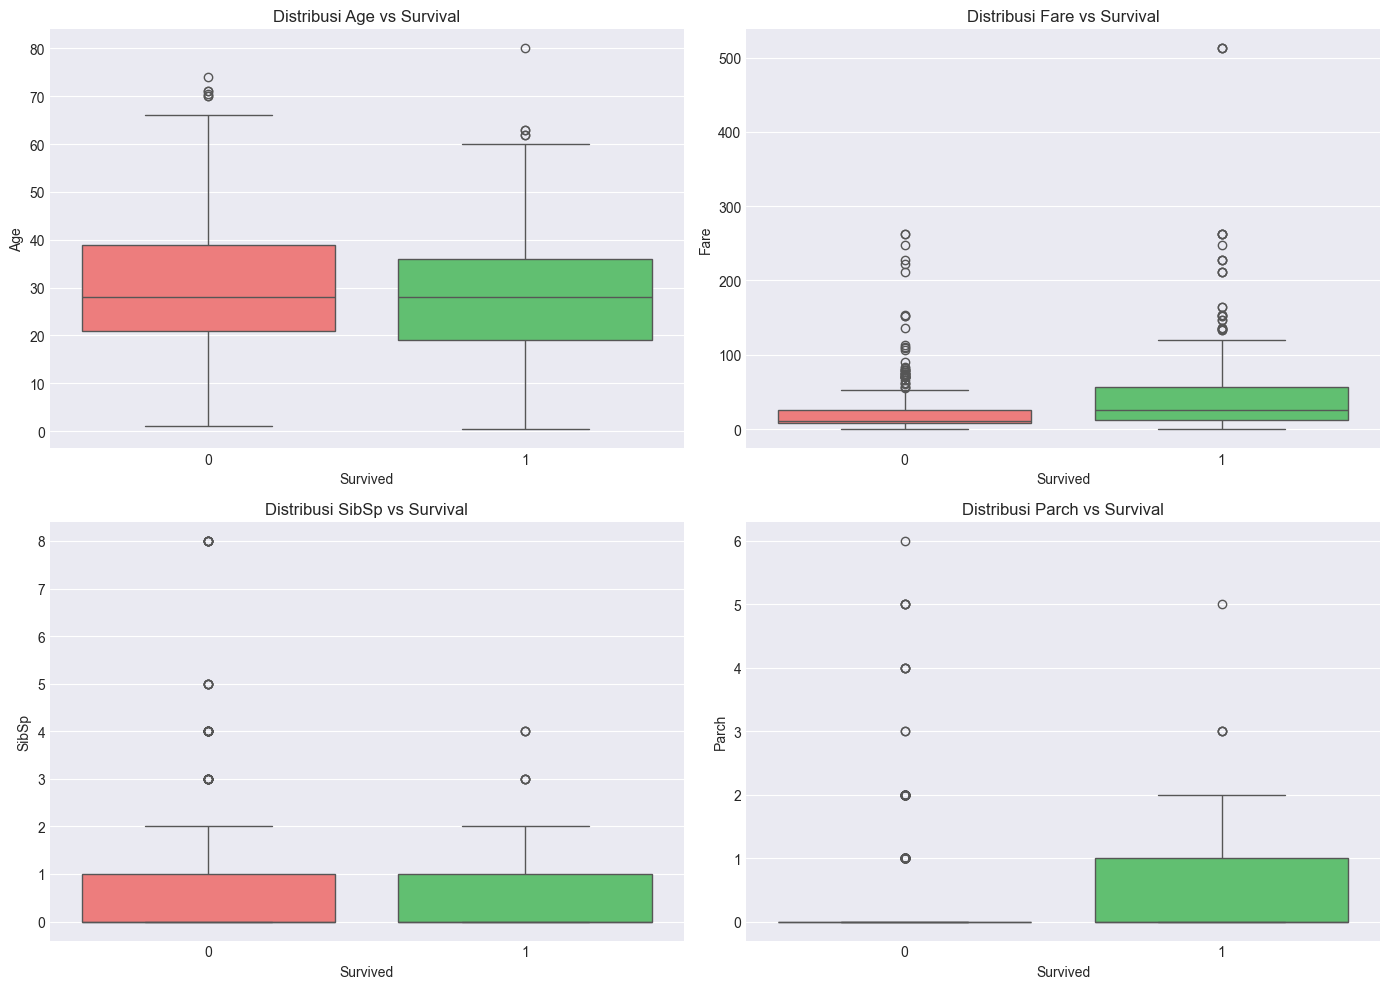

In [15]:
print("="*60)
print("📊 ANALISIS FITUR NUMERIK VS SURVIVAL")
print("="*60)

numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feature in enumerate(numeric_features):
    row = idx // 2
    col = idx % 2
    
    sns.boxplot(data=df, x='Survived', y=feature, ax=axes[row, col], palette=['#ff6b6b', '#51cf66'])
    axes[row, col].set_title(f'Distribusi {feature} vs Survival')

plt.tight_layout()
plt.savefig('numeric_vs_survival.png', dpi=150)
plt.show()

📊 ANALISIS FITUR KATEGORIKAL VS SURVIVAL


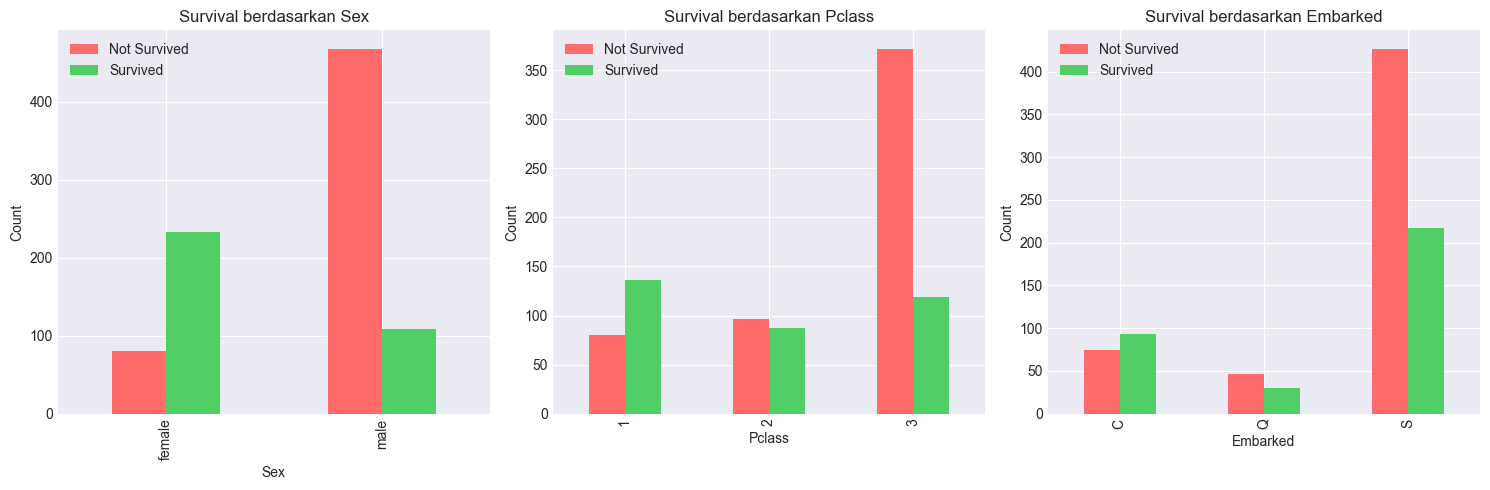

In [16]:
print("="*60)
print("📊 ANALISIS FITUR KATEGORIKAL VS SURVIVAL")
print("="*60)

categorical_features = ['Sex', 'Pclass', 'Embarked']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, feature in enumerate(categorical_features):
    crosstab = pd.crosstab(df[feature], df['Survived'])
    crosstab.plot(kind='bar', ax=axes[idx], color=['#ff6b6b', '#51cf66'])
    axes[idx].set_title(f'Survival berdasarkan {feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Count')
    axes[idx].legend(['Not Survived', 'Survived'])

plt.tight_layout()
plt.savefig('categorical_vs_survival.png', dpi=150)
plt.show()

In [17]:
print("="*60)
print("⚙️ PREPROCESSING DATA TITANIC")
print("="*60)

df_processed = df.copy()

# Drop kolom tidak berguna
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_processed.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"✓ Kolom di-drop: {cols_to_drop}")

# Handling Missing Values
age_median = df_processed.groupby('Pclass')['Age'].transform('median')
df_processed['Age'] = df_processed['Age'].fillna(age_median)
print("✓ Age: filled with median per Pclass")

df_processed['Embarked'] = df_processed['Embarked'].fillna('S')
print("✓ Embarked: filled with mode (S)")

# Encoding
le_sex = LabelEncoder()
df_processed['Sex'] = le_sex.fit_transform(df_processed['Sex'])
print("✓ Sex: encoded")

le_embarked = LabelEncoder()
df_processed['Embarked'] = le_embarked.fit_transform(df_processed['Embarked'])
print("✓ Embarked: encoded")

# Scaling
scaler = StandardScaler()
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']
df_processed[numeric_cols] = scaler.fit_transform(df_processed[numeric_cols])
print(f"✓ {len(numeric_cols)} numeric columns scaled")

print("\n" + "="*60)
print("✅ PREPROCESSING COMPLETE!")
print("="*60)

⚙️ PREPROCESSING DATA TITANIC
✓ Kolom di-drop: ['PassengerId', 'Name', 'Ticket', 'Cabin']
✓ Age: filled with median per Pclass
✓ Embarked: filled with mode (S)
✓ Sex: encoded
✓ Embarked: encoded
✓ 4 numeric columns scaled

✅ PREPROCESSING COMPLETE!


In [19]:
import os

os.makedirs('namadataset_preprocessing', exist_ok=True)

df_processed.to_csv('namadataset_preprocessing/data_preprocessed.csv', index=False)
print("✓ Data preprocessing saved!")

# Split data
X = df_processed.drop(columns=['Survived'])
y = df_processed['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

os.makedirs('namadataset_preprocessing/split', exist_ok=True)

X_train.to_csv('namadataset_preprocessing/split/X_train.csv', index=False)
X_test.to_csv('namadataset_preprocessing/split/X_test.csv', index=False)
y_train.to_csv('namadataset_preprocessing/split/y_train.csv', index=False)
y_test.to_csv('namadataset_preprocessing/split/y_test.csv', index=False)

print(f"\nData Split:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test: {y_test.shape}")
print(f"\n✅ All data saved to: preprocessing/namadataset_preprocessing/")

✓ Data preprocessing saved!

Data Split:
  X_train: (712, 7)
  X_test: (179, 7)
  y_train: (712,)
  y_test: (179,)

✅ All data saved to: preprocessing/namadataset_preprocessing/
